In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

## Configuration


### Path Configuration


#### Log File Names


In [163]:
PDR_LOG_FILE = "log_PDR.csv"
LATENCY_LOG_FILE = "log_e2eLat.csv"
PARENT_CHG_LOG_FILE = "log_ParChg.csv"
APP_LOG_FILE = "log_app.csv"
PARAMETERS_FILE = "parameters.txt"
IT_FILE = "log_IT.csv"
NEIGHBORS_FILE = "log_NeighborTable.csv"
POSITIONS_FILE = "log_positions.csv"

#### Specific Analysis Configuration

In [186]:
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20251120_11-00-03").resolve()
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20251121_23-09-00").resolve()
PATH_TO_RESULTS_PARENT_FOLDER = Path("../../results/batch_20260204_17-30-33").resolve()
TOPOLOGY_FOLDER_TO_ANALYZE = "random_20N"
CHANNEL_TYPE_TO_ANALYZE = "lossy"
# CHANNEL_TYPE_TO_ANALYZE = "unstable"
SEED_TO_ANALYZE = "12345"

## Main Analysis


In [187]:
analysis_base_path = (
    PATH_TO_RESULTS_PARENT_FOLDER
    / TOPOLOGY_FOLDER_TO_ANALYZE
    / CHANNEL_TYPE_TO_ANALYZE
    / SEED_TO_ANALYZE
)

if not analysis_base_path.exists():
    print(f"CRITICAL ERROR: Path does not exist: {analysis_base_path}")
    sys.exit(1)

#### Read the Neighbor Table and Positions

In [188]:
neighbor_df = pd.read_csv(analysis_base_path / NEIGHBORS_FILE)
positions_df = pd.read_csv(analysis_base_path / POSITIONS_FILE)

In [189]:
neighbor_df.head()

,Unnamed: 0,timestamp,node_id,neighbor,type,nexthop,hops,etx,adv_metric,age,log_num
0,0,40.0,Node-1,0011,NODE_CHILD,0011,1,9.882133,8.931751,34.132754,1
1,1,40.0,Node-1,0005,NODE_CHILD,0005,1,8.164122,7.919825,6.206392,1
2,2,40.0,Node-1,0006,NODE_DESCENTANT,0011,2,9.387263,17.549853,inf,1
3,3,40.0,Node-1,000e,NODE_DESCENTANT,0011,2,9.378960,17.729036,inf,1
4,4,40.0,Node-1,0013,NODE_DESCENTANT,0011,41,0.000000,inf,inf,1


#### Convert The IDs to a common Format

In [190]:
# Transform neighbor column from "hex" format to "Node-<dec>" format
neighbor_df["neighbor"] = neighbor_df["neighbor"].map(lambda x: f"Node-{int(x, 16)}")
neighbor_df.head()

,Unnamed: 0,timestamp,node_id,neighbor,type,nexthop,hops,etx,adv_metric,age,log_num
0,0,40.0,Node-1,Node-17,NODE_CHILD,0011,1,9.882133,8.931751,34.132754,1
1,1,40.0,Node-1,Node-5,NODE_CHILD,0005,1,8.164122,7.919825,6.206392,1
2,2,40.0,Node-1,Node-6,NODE_DESCENTANT,0011,2,9.387263,17.549853,inf,1
3,3,40.0,Node-1,Node-14,NODE_DESCENTANT,0011,2,9.378960,17.729036,inf,1
4,4,40.0,Node-1,Node-19,NODE_DESCENTANT,0011,41,0.000000,inf,inf,1


#### Connectivity Graph and Tree Construction

In [191]:
# Build connectivity graph at a specific time
def build_connectivity_graph(
    neighbor_df: pd.DataFrame, timestamp: int, nodes_list: list[str] = []
) -> nx.Graph:

    G = nx.Graph()

    # Filter to specific timestamp window
    window = neighbor_df[
        (neighbor_df["timestamp"] >= timestamp - 5)
        & (neighbor_df["timestamp"] <= timestamp + 5)
    ]

    for _, row in window.iterrows():
        # Add bidirectional edge if they're neighbors
        if row["type"] in [
            "NODE_NEIGHBOR",
            "NODE_PARENT",
            "NODE_CHILD",
            "NODE_DESCENTANT",
        ]:
            G.add_edge(row["node_id"], row["neighbor"])
        else:
            raise ValueError(f"Unknown neighbor type: {row['type']}")

    for node in nodes_list:
        if node not in G:
            G.add_node(node)

    return G


def build_tree_topology(
    neighbor_df: pd.DataFrame, timestamp: int, nodes_list: list[str] = []
) -> nx.DiGraph:

    G = nx.DiGraph()

    # Filter to specific timestamp window
    window = neighbor_df[
        (neighbor_df["timestamp"] >= timestamp - 5)
        & (neighbor_df["timestamp"] <= timestamp + 5)
    ]

    for _, row in window.iterrows():
        if row["type"] == "NODE_PARENT":
            G.add_edge(row["neighbor"], row["node_id"])
        elif row["type"] == "NODE_CHILD":
            G.add_edge(row["node_id"], row["neighbor"])

    for node in nodes_list:
        if node not in G:
            G.add_node(node)

    return G

#### Specific Time Stamp Analysis

In [192]:
neighbor_logging_time = 80

connectivity_graph = build_connectivity_graph(
    neighbor_df,
    timestamp=neighbor_logging_time,
    nodes_list=positions_df["node_id"].tolist(),
)

tree = build_tree_topology(
    neighbor_df,
    timestamp=neighbor_logging_time,
    nodes_list=positions_df["node_id"].tolist(),
)

#### Compute Pairwise Shortest Paths and Hop Stretch

In [193]:
def pairwise_shortest_paths(
    connectivity_graph: nx.Graph, tree: nx.DiGraph
) -> pd.DataFrame:
    psp_df = pd.DataFrame(
        columns=["from", "to", "cg_path_length", "tree_path_length"]
    )  # Pairwise Shortest Paths

    for node_a in connectivity_graph.nodes():
        for node_b in connectivity_graph.nodes():
            if (
                node_a != node_b and node_b not in psp_df["from"].values
            ):  # Do not check both (A->B and B->A)
                try:
                    cg_length = nx.shortest_path_length(
                        connectivity_graph, source=node_a, target=node_b
                    )
                except nx.NetworkXNoPath:
                    cg_length = np.nan
                try:
                    tree_length = nx.shortest_path_length(
                        nx.Graph.to_undirected(tree, as_view=True),
                        source=node_a,
                        target=node_b,
                    )
                except nx.NetworkXNoPath:
                    tree_length = np.nan
                except nx.NodeNotFound:
                    tree_length = np.nan
                psp_df = pd.concat(
                    [
                        psp_df,
                        pd.DataFrame(
                            {
                                "from": [node_a],
                                "to": [node_b],
                                "cg_path_length": [cg_length],
                                "tree_path_length": [tree_length],
                            }
                        ),
                    ],
                    ignore_index=True,
                )
    return psp_df


def compute_hop_stretch(psp_df: pd.DataFrame) -> pd.DataFrame:
    psp_df["hop_stretch"] = psp_df["tree_path_length"] / psp_df["cg_path_length"]
    return psp_df

In [194]:
psp_df = pairwise_shortest_paths(connectivity_graph, tree)

print(f"Number of node pairs: {len(psp_df)}")
psp_df.head()

Number of node pairs: 190


,from,to,cg_path_length,tree_path_length
0,Node-1,Node-17,1,1
1,Node-1,Node-5,1,1
2,Node-1,Node-6,1,2
3,Node-1,Node-14,1,2
4,Node-1,Node-19,1,3


In [195]:
hop_stretch_df = compute_hop_stretch(psp_df)

print(f"Mean hop stretch: {hop_stretch_df['hop_stretch'].mean():.2f}")
print(f"Median hop stretch: {hop_stretch_df['hop_stretch'].median():.2f}")
print(f"Standard Deviation of hop stretch: {hop_stretch_df['hop_stretch'].std():.2f}")
hop_stretch_df.describe()

Mean hop stretch: 2.20
Median hop stretch: 2.00
Standard Deviation of hop stretch: 0.78


,from,to,cg_path_length,tree_path_length,hop_stretch
count,190,190,91,91,91.0
unique,19,19,2,7,7.0
top,Node-1,Node-20,2,3,2.0
freq,19,19,46,20,28.0


#### Read the Physical Positions and Visualize the Graphs

In [196]:
phy_pos = {row["node_id"]: (row["x"], row["y"]) for _, row in positions_df.iterrows()}
positions_df.head()

,node_id,address,x,y,is_sink
0,Node-1,0001,46.453253,6.290317,True
1,Node-2,0002,-58.258008,-86.990135,False
2,Node-3,0003,-60.136653,-55.091019,False
3,Node-4,0004,-76.092143,9.128145,False
4,Node-5,0005,12.329549,26.252560,False


#### Connectivity Graph on the Physical Layout

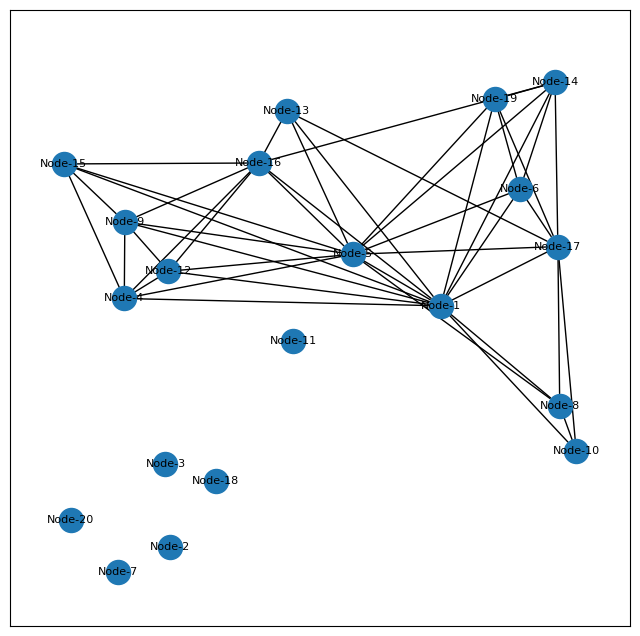

In [197]:
plt.figure(figsize=(8, 8))

nx.draw_networkx_nodes(
    connectivity_graph,
    phy_pos,
    # node_size=800
)

nx.draw_networkx_labels(
    connectivity_graph,
    phy_pos,
    font_size=8,
)

nx.draw_networkx_edges(
    connectivity_graph,
    phy_pos,
    arrows=True,
    # connectionstyle="arc3,rad=0.45" # Uncomment to visualize edges as arcs (for better visibility when nodes are aligned
)
plt.axis("equal")
plt.grid(False)
plt.show()

#### Tree Graph on the Physical Layout

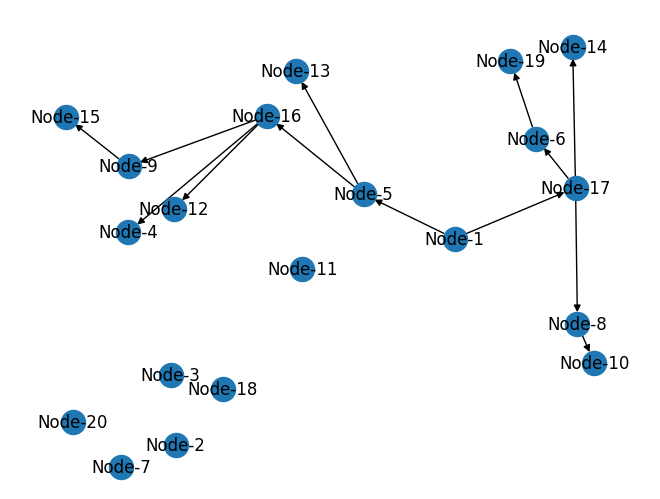

In [198]:
nx.draw(tree, phy_pos, with_labels=True)
plt.show()

#### Tree Graph on the Hierarchical Layout

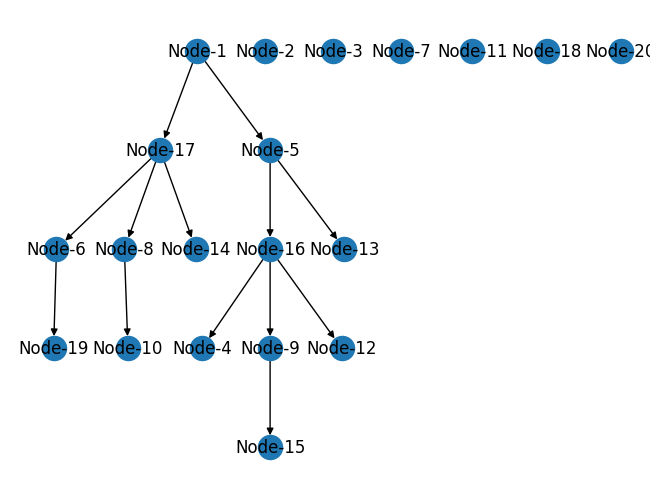

In [199]:
tree_pos = graphviz_layout(tree, prog="dot")
nx.draw(tree, tree_pos, with_labels=True)
plt.show()